# 과적합

- 훈련데이터에 모델이 지나치게 최적화 되어, 다른 데이터를 반영하지 못함
- 데이터가 적거나 모델이 너무 복잡한 경우


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
from datasets.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

x_train = x_train[:300]
t_train = t_train[:300]

In [ ]:
from b1.module.multi_layer_net import MultiLayerNet
from b1.module.optimizer import SGD
from b1.module.trainer import Trainer

net = MultiLayerNet(
    input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10
)

max_epochs = 300
train_size = x_train.shape[0]
batch_size = 100

overfit_trainer = Trainer(
    net,
    x_train,
    t_train,
    x_test,
    t_test,
    max_epochs,
    batch_size,
)

overfit_trainer.train()

train loss:2.4697458789418913
train loss:2.4123788504612578
train loss:2.320352374211291
train loss:2.314584888782358
train loss:2.2817011393994022
train loss:2.247184646839704
train loss:2.260324849118772
train loss:2.226888842181545
train loss:2.2507898120130823
train loss:2.18708823669696
train loss:2.193452173534067
train loss:2.1778647642168467
train loss:2.1536695949032225
train loss:2.190967548917582
train loss:2.0813971525318222
train loss:2.128614279374892
train loss:2.132995655742417
train loss:2.1130161841856823
train loss:2.0863542270759154
train loss:2.1122607123210937
train loss:2.0709136022483303
train loss:2.0764759005062605
train loss:2.0334113893288417
train loss:2.0748112610792235
train loss:2.0488957774835432
train loss:2.0962893426125198
train loss:2.0162963861940306
train loss:2.0051258835805883
train loss:1.9989931052427772
train loss:1.998124685238567
train loss:1.984626139578961
train loss:1.966137513013308
train loss:1.9377426058644027
train loss:1.88928889631

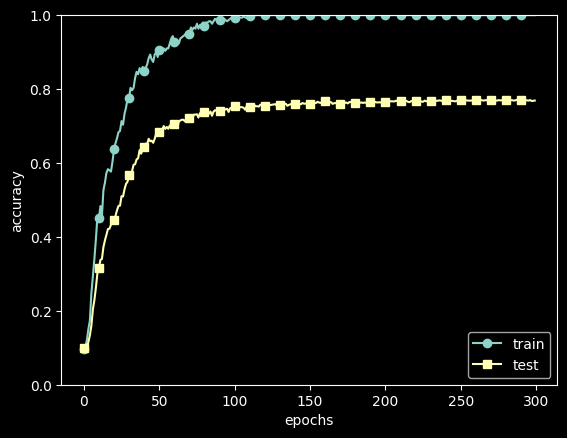

In [ ]:
markers = {"train": "o", "test": "s"}
x = np.arange(max_epochs)
plt.plot(x, overfit_trainer.train_acc_list, marker="o", label="train", markevery=10)
plt.plot(x, overfit_trainer.test_acc_list, marker="s", label="test", markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc="lower right")
plt.show()

## 가중치 감소

- 큰 가중치에 패널티
  - $$L + \frac{1}{2} W^2$$
- 과대 적합 방지


In [21]:
decay_net = MultiLayerNet(
    input_size=784,
    hidden_size_list=[100, 100, 100, 100, 100, 100],
    output_size=10,
    weight_decay_lambda=0.1,
)
decay_trainer = Trainer(
    decay_net,
    x_train,
    t_train,
    x_test,
    t_test,
    max_epochs,
    batch_size,
)
decay_trainer.train()

train loss:63.65242058354168


train loss:63.5030755850428
train loss:63.38641387939046
train loss:63.28400006858033
train loss:63.18512258683925
train loss:63.033145183712925
train loss:62.90907382276613
train loss:62.74206040889397
train loss:62.57659196073226
train loss:62.51938270688669
train loss:62.37442071785242
train loss:62.2673039067771
train loss:62.1008238078224
train loss:61.98812724360835
train loss:61.87586107821848
train loss:61.72815500575579
train loss:61.64329862056929
train loss:61.51852690542551
train loss:61.34993827825754
train loss:61.238267893497856
train loss:61.10733371032623
train loss:61.037748935213955
train loss:60.911487925343025
train loss:60.76462974974965
train loss:60.603530622565856
train loss:60.53886143641615
train loss:60.41602958293763
train loss:60.2537080336437
train loss:60.16229508629264
train loss:60.03408547753545
train loss:59.89263252834779
train loss:59.768404930888885
train loss:59.650210118946504
train loss:59.565625028557655
train loss:59.45022939490255
train loss

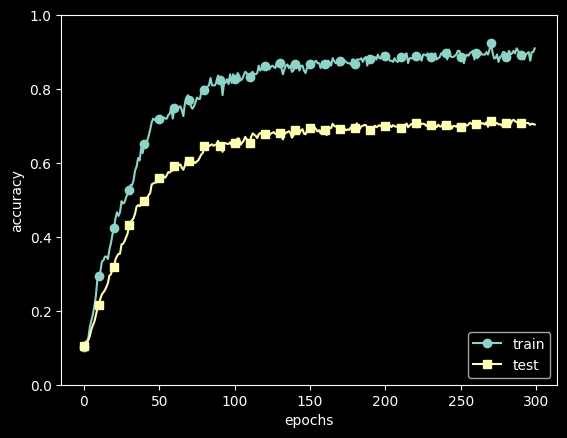

In [22]:
markers = {"train": "o", "test": "s"}
x = np.arange(max_epochs)
plt.plot(x, decay_trainer.train_acc_list, marker="o", label="train", markevery=10)
plt.plot(x, decay_trainer.test_acc_list, marker="s", label="test", markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc="lower right")
plt.show()

# 드롭아웃

- 일부 노드 연결을 비활성화


In [23]:
class Dropout:
    def __init__(self, ratio=0.5):
        self.ratio = ratio
        self.mask = None

    def forward(self, x, train_flag=True):
        if train_flag:
            self.mask = np.random.rand(*x.shape) > self.ratio
            return x * self.mask
        else:
            return x * (1.0 - self.ratio)

    def backword(self, dout):
        return dout * self.mask

In [24]:
from b1.module.multi_layer_net_extend import MultiLayerNetExtend

dropout_net = MultiLayerNetExtend(
    input_size=784,
    hidden_size_list=[100, 100, 100, 100, 100, 100],
    output_size=10,
    use_dropout=True,
    dropout_ration=0.15,
)

dropout_trainer = Trainer(
    dropout_net,
    x_train,
    t_train,
    x_test,
    t_test,
    max_epochs,
    batch_size,
)
dropout_trainer.train()

train loss:2.328483361420518
train loss:2.323117968355203
train loss:2.33181747235113
train loss:2.3414605174259564
train loss:2.329655788957518
train loss:2.3285320109315935
train loss:2.325582051073922
train loss:2.3119140428640983
train loss:2.301870821667004
train loss:2.3268050876149964
train loss:2.337321165156279
train loss:2.3152575325987117
train loss:2.3161478252265346
train loss:2.319236133942354
train loss:2.324067335651977
train loss:2.3177823673110667
train loss:2.321192038777679
train loss:2.2986603518294078
train loss:2.31324719504433
train loss:2.3153656067799857
train loss:2.3048268864716746
train loss:2.296571053780089
train loss:2.2912424752356646
train loss:2.2986540794414405
train loss:2.293420194727471
train loss:2.294273172047803
train loss:2.3133268991955003
train loss:2.3044709136084194
train loss:2.2991262861182262
train loss:2.30737851238099
train loss:2.3104533350824066
train loss:2.310961775056088
train loss:2.3012140671564087
train loss:2.298410487060474


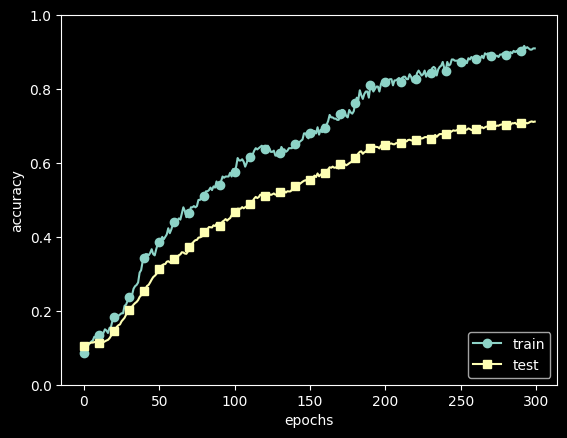

In [25]:
markers = {"train": "o", "test": "s"}
x = np.arange(max_epochs)
plt.plot(x, dropout_trainer.train_acc_list, marker="o", label="train", markevery=10)
plt.plot(x, dropout_trainer.test_acc_list, marker="s", label="test", markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc="lower right")
plt.show()